In [73]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import glob

img = cv2.imread('templates/2_4.png', cv2.IMREAD_GRAYSCALE)
paths = glob.glob('templates/*.png')

In [74]:
def prepare_template(file_path, threshold_value=200):
    template = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    if template is None:
        raise ValueError(f"Could not read the image at {file_path}")
    _, binary = cv2.threshold(template, threshold_value, 255, cv2.THRESH_BINARY_INV)

    coords = cv2.findNonZero(binary)
    x, y, w, h = cv2.boundingRect(coords)

    template_cropped = binary[y:y+h, x:x+w]
    output_path = os.path.join("patterns", os.path.basename(file_path))
    cv2.imwrite(output_path, template_cropped)
    return template_cropped


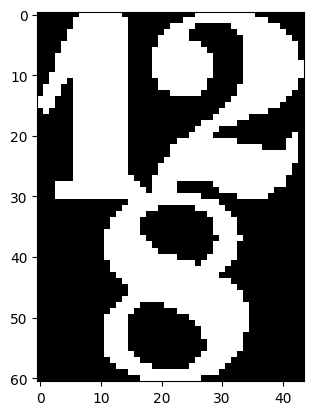

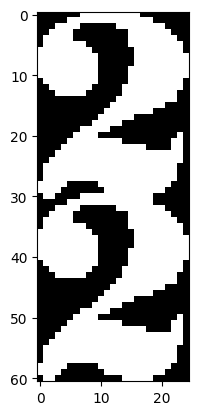

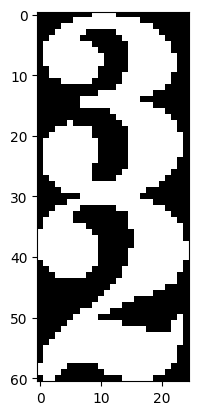

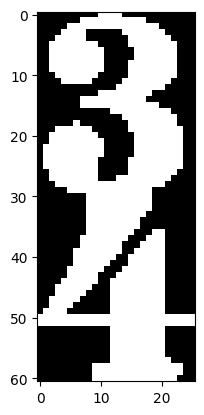

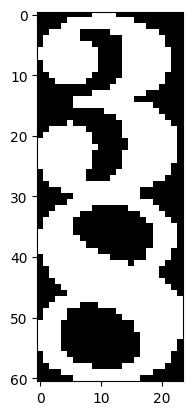

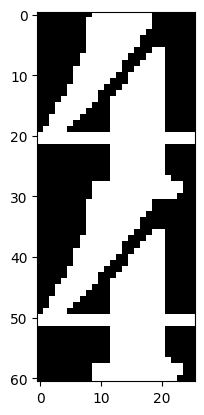

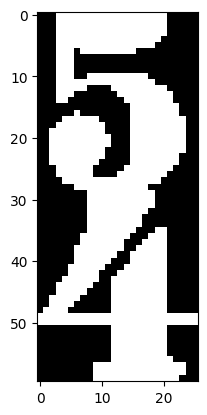

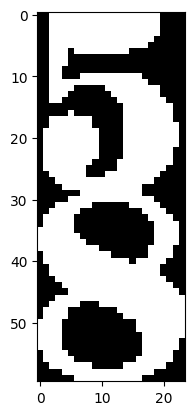

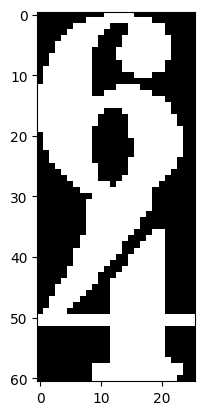

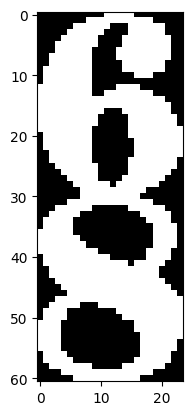

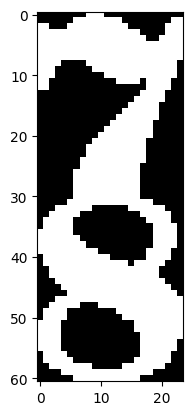

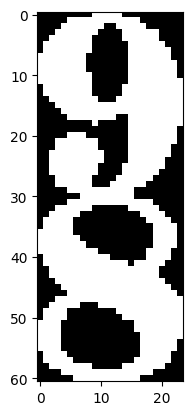

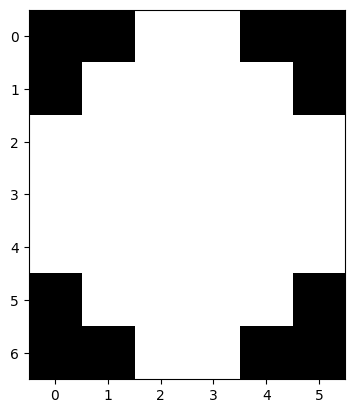

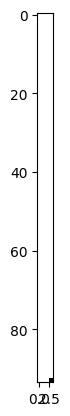

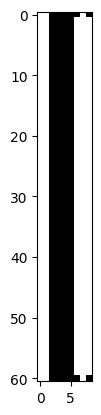

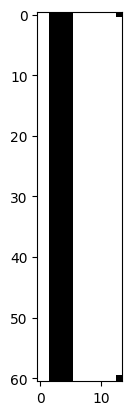

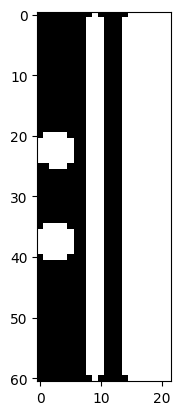

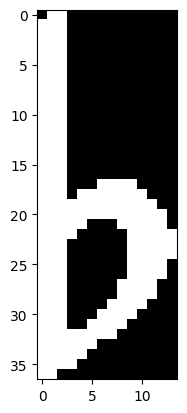

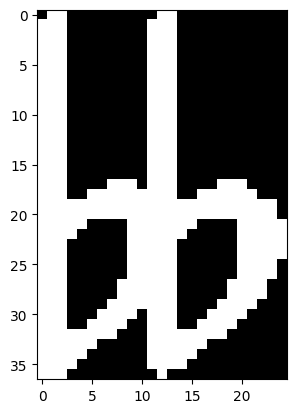

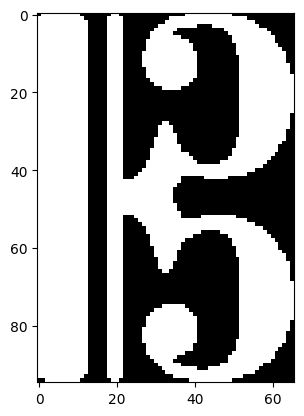

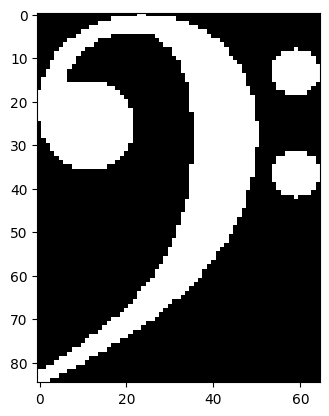

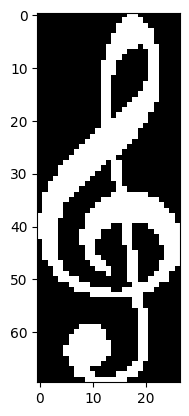

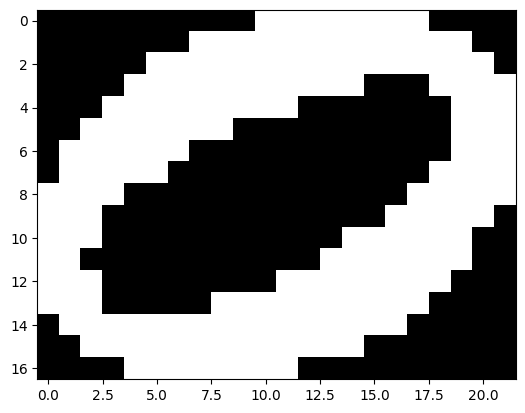

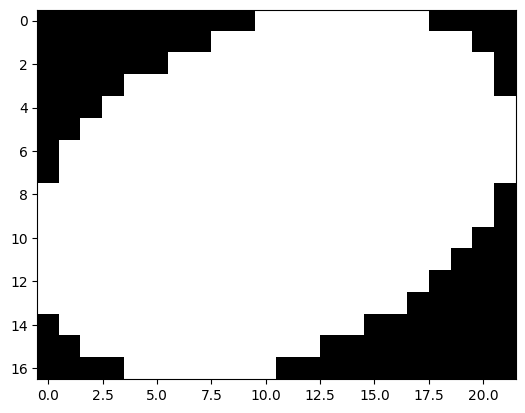

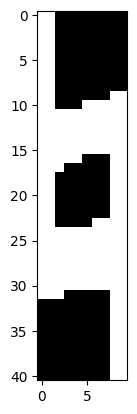

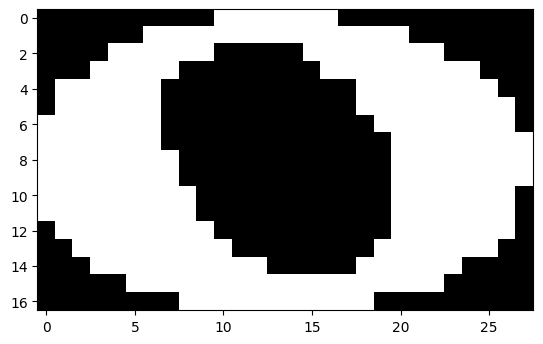

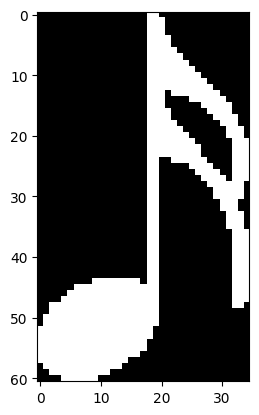

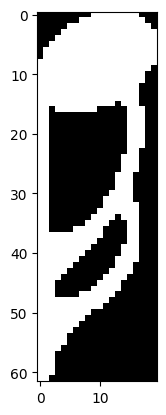

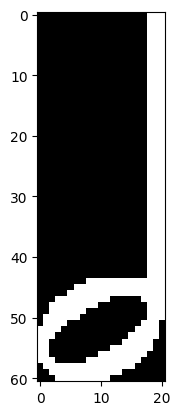

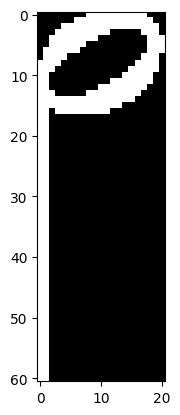

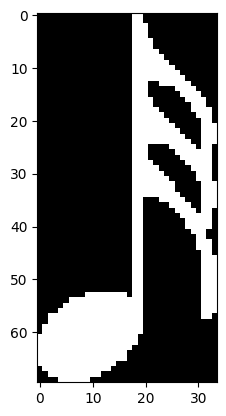

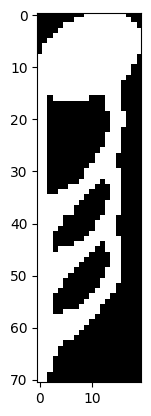

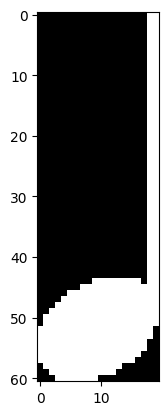

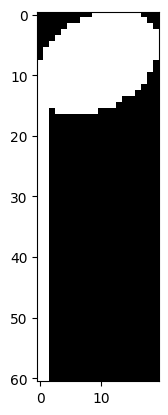

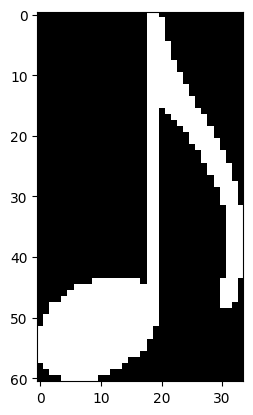

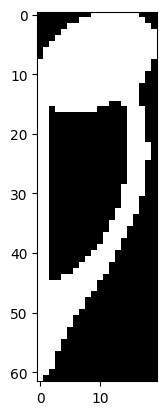

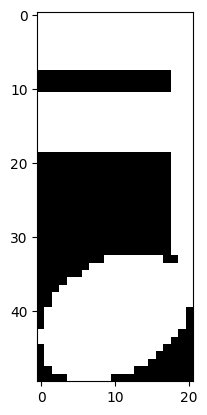

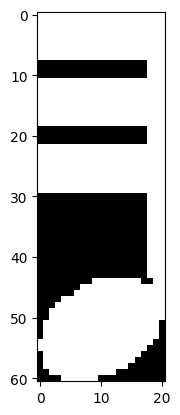

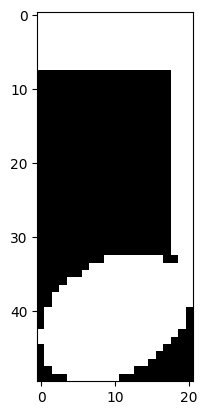

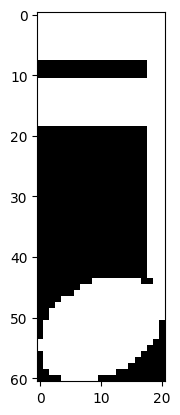

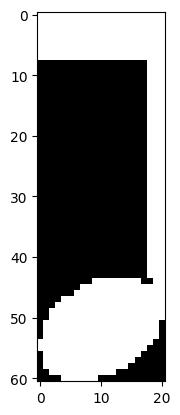

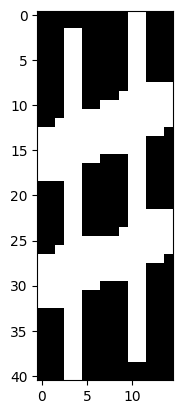

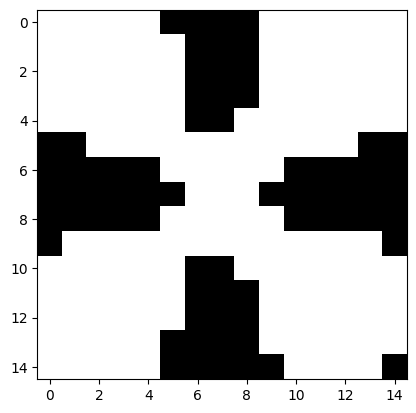

In [75]:
for path in paths:
    template = prepare_template(path)
    plt.imshow(template, cmap='gray')
    plt.show()

In [41]:
def display_img(img):
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()

def resize_img(img, scale_factor):
    return cv2.resize(img, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_CUBIC)

def threshold_img(img, threshold_value, Otsu=False):
    _, img_bin = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY_INV)
    if Otsu:
        _, img_bin = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    else:
        _, img_bin = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY_INV)
    return img_bin

In [42]:
def rotate_img(img):
    rows, cols = img.shape
    min_line_length = 100 if cols > 100 else 50

    lines = cv2.HoughLinesP(img, 1, np.pi / 180, threshold=100, minLineLength=min_line_length, maxLineGap=10)

    angles = []
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
            if abs(angle) < 15:  # Tylko podobne do poziomych linii
                angles.append(angle)
    
    if len(angles) > 0:
        median_angle = np.median(angles)
        print(f"Wykryto skos: {median_angle:.2f} stopni")
        print(rows, cols)
        center = (cols // 2, rows // 2)
        rotation_matrix = cv2.getRotationMatrix2D(center, median_angle, 1.)
        rotated_img = cv2.warpAffine(img, rotation_matrix, (cols, rows), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_CONSTANT, borderValue=255)
        
        imb_bin = threshold_img(rotated_img, 200, Otsu=False)

        return rotated_img
    else:
        print("Nie wykryto skosu.")
        return img


In [49]:
def pipeline(img):
    img_enlarged = resize_img(img,3)
    img_bin = threshold_img(img, 200, Otsu=False)
    rotated_img = rotate_img(img_bin)

    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (100, 1))
    detected_lines = cv2.morphologyEx(rotated_img, cv2.MORPH_OPEN, horizontal_kernel, iterations=1)
    lines_inverted = cv2.bitwise_not(detected_lines)
    notes_only_img = cv2.bitwise_and(rotated_img, rotated_img, mask=lines_inverted)
    
    
    notes_only_img = cv2.morphologyEx(notes_only_img, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    notes_only_img = cv2.morphologyEx(notes_only_img, cv2.MORPH_CLOSE, np.ones((15, 1), np.uint8), iterations=1)
    
    return notes_only_img

In [44]:
# img_enlarged = resize_img(img,3)
# img_bin = threshold_img(img_enlarged, 200, Otsu=False)
# img_bin = cv2.morphologyEx(img_bin, cv2.MORPH_CLOSE, np.ones((2, 2), np.uint8))
# display_img(img_bin)

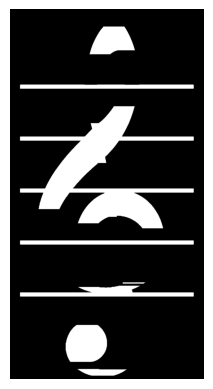

In [45]:
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (100, 1))
detected_lines = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, horizontal_kernel, iterations=1)
display_img(detected_lines)

Nie wykryto skosu.


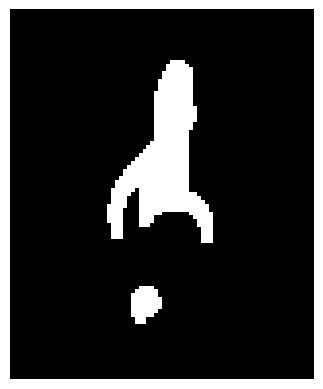

In [55]:
display_img(pipeline(img))

In [47]:
paths = glob.glob('../data/note_pitches_selected/*.png')

symbols = [cv2.imread(path, cv2.IMREAD_GRAYSCALE) for path in paths]

Nie wykryto skosu.


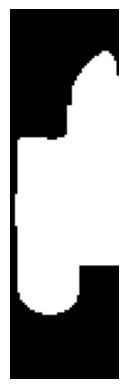

Nie wykryto skosu.


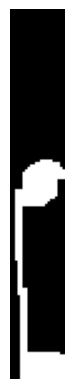

Nie wykryto skosu.


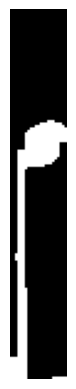

Nie wykryto skosu.


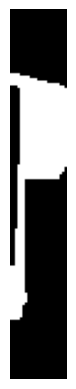

Nie wykryto skosu.


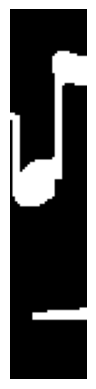

Nie wykryto skosu.


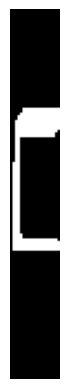

Nie wykryto skosu.


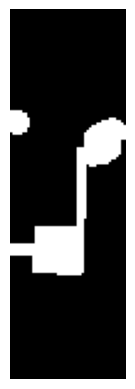

Nie wykryto skosu.


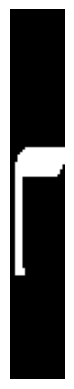

Nie wykryto skosu.


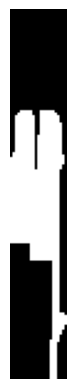

Nie wykryto skosu.


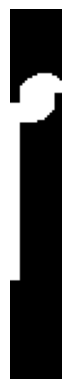

In [48]:
for i in range(10):
    display_img(pipeline(symbols[i]))